In [ ]:
!pip install darts

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import missingno as mno

import warnings
warnings.filterwarnings("ignore")
import logging
logging.disable(logging.CRITICAL)



from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TransformerModel
from darts.metrics import mape, rmse
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.utils.likelihood_models import QuantileRegression



pd.set_option("display.precision",2)
np.set_printoptions(precision=2, suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
LOAD = False         # True = load previously saved model from disk?  False = (re)train the model
SAVE = "TForm_model.pth.tar"   # file name to save the model under

EPOCHS = 200
INLEN = 32          # input size
FEAT = 32           # d_model = number of expected features in the inputs, up to 512
HEADS = 4           # default 8
ENCODE = 4          # encoder layers
DECODE = 4          # decoder layers
DIM_FF = 128        # dimensions of the feedforward network, default 2048
BATCH = 32          # batch size
ACTF = "relu"       # activation function, relu (default) or gelu
SCHLEARN = None     # a PyTorch learning rate scheduler; None = constant rate
LEARN = 1e-3        # learning rate
VALWAIT = 1         # epochs to wait before evaluating the loss on the test/validation set
DROPOUT = 0.1       # dropout rate
N_FC = 1            # output size

RAND = 42           # random seed
N_SAMPLES = 100     # number of times a prediction is sampled from a probabilistic model
N_JOBS = 3          # parallel processors to use;  -1 = all processors

# default quantiles for QuantileRegression
QUANTILES = [0.01, 0.1, 0.2, 0.5, 0.8, 0.9, 0.99]

SPLIT = 0.9         # train/test %

FIGSIZE = (9, 6)


qL1, qL2 = 0.01, 0.10        # percentiles of predictions: lower bounds
qU1, qU2 = 1-qL1, 1-qL2,     # upper bounds derived from lower bounds
label_q1 = f'{int(qU1 * 100)} / {int(qL1 * 100)} percentile band'
label_q2 = f'{int(qU2 * 100)} / {int(qL2 * 100)} percentile band'

mpath = os.path.abspath(os.getcwd()) + SAVE     # path and file name to save the model

# Time Series Object

In [ ]:
import pickle

with open('DE_predict.pickle','rb') as f:
    df4 = pickle.load(f)

In [8]:
df4

,price_actual,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,...,temp_Hamburg,temp_Aachen,temp_Stuttgart,temp_Munchen,max_temp_Aachen,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar
Time,,,,,,,,,,,,,,,,,,,,,
2024-06-30 22:00:00,87.24,79.59,"3,575.25","9,123.25","1,287.25","3,712.50",569.75,675.50,"40,902.00",86.00,...,15.79,15.79,15.79,15.79,16.63,16.63,16.63,16.63,16.63,3.00
2024-06-30 23:00:00,78.77,73.22,"3,598.25","9,088.75","1,253.50","3,625.50",222.50,603.50,"39,814.50",88.00,...,15.92,15.92,15.92,15.92,16.63,16.63,16.63,16.63,16.63,3.00
2024-07-01 00:00:00,75.74,73.30,"3,356.00","9,228.50","1,155.25","3,612.00",74.50,326.00,"38,859.50",87.00,...,15.10,15.10,15.10,15.10,16.08,16.08,16.08,16.08,16.08,3.00
2024-07-01 01:00:00,76.01,74.00,"3,744.00","9,509.00","1,162.75","3,603.50",81.25,392.50,"38,633.50",87.00,...,14.31,14.31,14.31,14.31,15.59,15.59,15.59,15.59,15.59,2.75
2024-07-01 02:00:00,74.68,73.72,"3,869.00","9,888.25","1,382.25","3,637.50",255.25,421.25,"39,898.25",87.00,...,13.80,13.80,13.80,13.80,14.95,14.95,14.95,14.95,14.95,5.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26 18:00:00,103.24,107.35,"2,819.25","7,412.75","2,428.50","3,867.25","2,288.50",238.75,"57,723.25",69.00,...,21.32,21.32,21.32,21.32,22.75,22.75,22.75,22.75,22.75,"2,056.50"
2025-06-26 19:00:00,103.70,107.40,"2,776.00","7,639.50","2,834.75","3,886.50","2,229.75",224.50,"54,980.75",71.00,...,20.79,20.79,20.79,20.79,22.20,22.20,22.20,22.20,22.20,167.25
2025-06-26 20:00:00,107.32,106.00,"2,915.75","7,894.50","2,559.00","3,886.75","2,493.25",267.00,"52,397.25",73.00,...,20.61,20.61,20.61,20.61,21.64,21.64,21.64,21.64,21.64,1.25


In [9]:
# create time series object for target variable
ts_P = TimeSeries.from_series(df4["price_actual"])

# check attributes of the time series
print("components:", ts_P.components)
print("duration:",ts_P.duration)
print("frequency:",ts_P.freq)
print("frequency:",ts_P.freq_str)
print("has date time index? (or else, it must have an integer index):",ts_P.has_datetime_index)
print("deterministic:",ts_P.is_deterministic)
print("univariate:",ts_P.is_univariate)

components: Index(['price_actual'], dtype='object')
duration: 361 days 00:00:00
frequency: <Hour>
frequency: h
has date time index? (or else, it must have an integer index): True
deterministic: True
univariate: True


In [10]:
# create time series object for the feature columns
df_covF = df4.loc[:, df4.columns != "price_actual"]
ts_covF = TimeSeries.from_dataframe(df_covF)

# check attributes of the time series
print("components (columns) of feature time series:", ts_covF.components)
print("duration:",ts_covF.duration)
print("frequency:",ts_covF.freq)
print("frequency:",ts_covF.freq_str)
print("has date time index? (or else, it must have an integer index):",ts_covF.has_datetime_index)
print("deterministic:",ts_covF.is_deterministic)
print("univariate:",ts_covF.is_univariate)


components (columns) of feature time series: Index(['price_dayahead', 'gen_gas', 'gen_lig', 'gen_coal', 'gen_bio',
       'gen_hyd_pump', 'gen_hyd_res', 'load_actual', 'humidity_Aachen',
       'humidity_Stuttgart', 'humidity_Hamburg', 'humidity_Berlin',
       'humidity_Munchen', 'gen_oil', 'gen_oth_renew', 'pressure_Munchen',
       'pressure_Berlin', 'pressure_Hamburg', 'pressure_Stuttgart',
       'pressure_Aachen', 'gen_wind', 'min_temp_Stuttgart', 'min_temp_Munchen',
       'min_temp_Aachen', 'min_temp_Hamburg', 'min_temp_Berlin', 'temp_Berlin',
       'temp_Hamburg', 'temp_Aachen', 'temp_Stuttgart', 'temp_Munchen',
       'max_temp_Aachen', 'max_temp_Berlin', 'max_temp_Munchen',
       'max_temp_Hamburg', 'max_temp_Stuttgart', 'gen_solar'],
      dtype='object')
duration: 361 days 00:00:00
frequency: <Hour>
frequency: h
has date time index? (or else, it must have an integer index): True
deterministic: True
univariate: False


In [11]:
# example: operating with time series objects:
# we can also create a 3-dimensional numpy array from a time series object
# 3 dimensions: time (rows) / components (columns) / samples
ar_covF = ts_covF.all_values()
print(type(ar_covF))
ar_covF.shape

<class 'numpy.ndarray'>


(8665, 37, 1)

In [ ]:
# example: operating with time series objects:
# we can also create a pandas series or dataframe from a time series object
df_covF = ts_covF.to_dataframe()
type(df_covF)

In [13]:
# train/test split and scaling of target variable
ts_train, ts_test = ts_P.split_after(SPLIT)
print("training start:", ts_train.start_time())
print("training end:", ts_train.end_time())
print("training duration:",ts_train.duration)
print("test start:", ts_test.start_time())
print("test end:", ts_test.end_time())
print("test duration:", ts_test.duration)


scalerP = Scaler()
scalerP.fit_transform(ts_train)
ts_ttrain = scalerP.transform(ts_train)
ts_ttest = scalerP.transform(ts_test)
ts_t = scalerP.transform(ts_P)

# make sure data are of type float
ts_t = ts_t.astype(np.float32)
ts_ttrain = ts_ttrain.astype(np.float32)
ts_ttest = ts_ttest.astype(np.float32)

print("first and last row of scaled price time series:")
pd.options.display.float_format = '{:,.2f}'.format
ts_t.to_dataframe().iloc[[0,-1]]

training start: 2024-06-30 22:00:00
training end: 2025-05-21 19:00:00
training duration: 324 days 21:00:00
test start: 2025-05-21 20:00:00
test end: 2025-06-26 22:00:00
test duration: 36 days 02:00:00
first and last row of scaled price time series:


,price_actual
Time,
2024-06-30 22:00:00,0.29
2025-06-26 22:00:00,0.31


In [14]:
# train/test split and scaling of feature covariates
covF_train, covF_test = ts_covF.split_after(SPLIT)

scalerF = Scaler()
scalerF.fit_transform(covF_train)
covF_ttrain = scalerF.transform(covF_train)
covF_ttest = scalerF.transform(covF_test)
covF_t = scalerF.transform(ts_covF)

# make sure data are of type float
covF_ttrain = covF_ttrain.astype(np.float32)
covF_ttest = covF_ttest.astype(np.float32)

pd.options.display.float_format = '{:.2f}'.format
print("first and last row of scaled feature covariates:")
covF_t.to_dataframe().iloc[[0,-1]]

first and last row of scaled feature covariates:


,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,humidity_Stuttgart,...,temp_Hamburg,temp_Aachen,temp_Stuttgart,temp_Munchen,max_temp_Aachen,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar
Time,,,,,,,,,,,,,,,,,,,,,
2024-06-30 22:00:00,0.29,0.11,0.60,0.11,0.24,0.08,0.66,0.19,0.81,0.81,...,0.56,0.56,0.56,0.56,0.55,0.55,0.55,0.55,0.55,0.00
2025-06-26 22:00:00,0.31,0.10,0.42,0.20,0.31,0.04,0.06,0.38,0.68,0.68,...,0.66,0.66,0.66,0.66,0.66,0.66,0.66,0.66,0.66,-0.00


In [15]:
# feature engineering - create time covariates: hour, weekday, month, year, country-specific holidays
covT = datetime_attribute_timeseries(   ts_P.time_index,
                                        attribute="hour",
                                        add_length=48, one_hot=False )
covT = covT.stack(datetime_attribute_timeseries(covT.time_index, attribute="day_of_week", one_hot=False))
covT = covT.stack(datetime_attribute_timeseries(covT.time_index, attribute="month", one_hot=False))
covT = covT.stack(datetime_attribute_timeseries(covT.time_index, attribute="year", one_hot=False))

covT = covT.add_holidays(country_code="DE")
covT = covT.astype(np.float32)


# train/test split
covT_train, covT_test = covT.split_after(covF_train.end_time())


# rescale the covariates: fitting on the training set
scalerT = Scaler()
scalerT.fit(covT_train)
covT_ttrain = scalerT.transform(covT_train)
covT_ttest = scalerT.transform(covT_test)
covT_t = scalerT.transform(covT)

covT_t = covT_t.astype(np.float32)


pd.options.display.float_format = '{:.0f}'.format
print("first and last row of unscaled time covariates:")
covT.to_dataframe().iloc[[0,-1]]

first and last row of unscaled time covariates:


,hour,day_of_week,month,year,holidays
Time,,,,,
2024-06-30 22:00:00,22,6,5,2024,0
2025-06-28 22:00:00,22,5,5,2025,0


In [16]:
# combine feature and time covariates along component dimension: axis=1
ts_cov = ts_covF.concatenate(covT.slice_intersect(ts_covF), axis=1)   # unscaled F+T
cov_t = covF_t.concatenate(covT_t.slice_intersect(covF_t), axis=1)    # scaled F+T
cov_ttrain = covF_ttrain.concatenate(covT_ttrain.slice_intersect(covF_ttrain), axis=1)  # scaled F+T training set
cov_ttest = covF_ttest.concatenate(covT_ttest.slice_intersect(covF_ttest), axis=1)      # scaled F+T test set


pd.options.display.float_format = '{:.2f}'.format
print("first and last row of unscaled covariates:")
ts_cov.to_dataframe().iloc[[0,-1]]

first and last row of unscaled covariates:


,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,humidity_Stuttgart,...,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar,hour,day_of_week,month,year,holidays
Time,,,,,,,,,,,,,,,,,,,,,
2024-06-30 22:00:00,79.59,3575.25,9123.25,1287.25,3712.50,569.75,675.50,40902.00,86.00,86.00,...,16.63,16.63,16.63,16.63,3.00,22.00,6.00,5.00,2024.00,0.00
2025-06-26 22:00:00,92.60,3407.00,7083.00,1998.00,3857.00,276.00,60.00,49127.00,76.00,76.00,...,20.89,20.89,20.89,20.89,0.00,22.00,3.00,5.00,2025.00,0.00


In [17]:
pd.options.display.float_format = '{:.2f}'.format
print("first and last row of scaled covariates, training + test set:")
cov_t.to_dataframe().iloc[[0,-1]]

first and last row of scaled covariates, training + test set:


,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,humidity_Stuttgart,...,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar,hour,day_of_week,month,year,holidays
Time,,,,,,,,,,,,,,,,,,,,,
2024-06-30 22:00:00,0.29,0.11,0.60,0.11,0.24,0.08,0.66,0.19,0.81,0.81,...,0.55,0.55,0.55,0.55,0.00,0.96,1.00,0.45,0.00,0.00
2025-06-26 22:00:00,0.31,0.10,0.42,0.20,0.31,0.04,0.06,0.38,0.68,0.68,...,0.66,0.66,0.66,0.66,-0.00,0.96,0.50,0.45,1.00,0.00


In [18]:
print("first and last row of scaled training set covariates:")
cov_ttrain.to_dataframe().iloc[[0,-1]]

first and last row of scaled training set covariates:


,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,humidity_Stuttgart,...,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar,hour,day_of_week,month,year,holidays
Time,,,,,,,,,,,,,,,,,,,,,
2024-06-30 22:00:00,0.29,0.11,0.60,0.11,0.24,0.08,0.66,0.19,0.81,0.81,...,0.55,0.55,0.55,0.55,0.00,0.96,1.00,0.45,0.00,0.00
2025-05-21 19:00:00,0.33,0.29,0.41,0.27,0.57,0.66,0.25,0.50,0.44,0.44,...,0.53,0.53,0.53,0.53,0.00,0.83,0.33,0.36,1.00,0.00


In [19]:
print("first and last row of scaled target variable in training set: price:")
ts_ttrain.to_dataframe().iloc[[0,-1]]

first and last row of scaled target variable in training set: price:


,price_actual
Time,
2024-06-30 22:00:00,0.29
2025-05-21 19:00:00,0.31


In [20]:
print("first and last row of scaled test set covariates:")
cov_ttest.to_dataframe().iloc[[0,-1]]

first and last row of scaled test set covariates:


,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,humidity_Stuttgart,...,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar,hour,day_of_week,month,year,holidays
Time,,,,,,,,,,,,,,,,,,,,,
2025-05-21 20:00:00,0.31,0.29,0.40,0.29,0.50,0.48,0.18,0.42,0.53,0.53,...,0.53,0.53,0.53,0.53,0.00,0.87,0.33,0.36,1.00,0.00
2025-06-26 22:00:00,0.31,0.10,0.42,0.20,0.31,0.04,0.06,0.38,0.68,0.68,...,0.66,0.66,0.66,0.66,-0.00,0.96,0.50,0.45,1.00,0.00


In [21]:
print("first and last row of scaled target variable in test set: price:")
ts_ttrain.to_dataframe().iloc[[0,-1]]

first and last row of scaled target variable in test set: price:


,price_actual
Time,
2024-06-30 22:00:00,0.29
2025-05-21 19:00:00,0.31


# Training: Transformer

In [22]:
model = TransformerModel(
                    input_chunk_length = INLEN,
                    output_chunk_length = N_FC,
                    batch_size = BATCH,
                    n_epochs = EPOCHS,
                    model_name = "Transformer_price",
                    nr_epochs_val_period = VALWAIT,
                    d_model = FEAT,
                    nhead = HEADS,
                    num_encoder_layers = ENCODE,
                    num_decoder_layers = DECODE,
                    dim_feedforward = DIM_FF,
                    dropout = DROPOUT,
                    activation = ACTF,
                    random_state=RAND,
                    likelihood=QuantileRegression(quantiles=QUANTILES),
                    optimizer_kwargs={'lr': LEARN},
                    add_encoders={"cyclic": {"future": ["hour", "dayofweek", "month"]}},
                    save_checkpoints=True,
                    force_reset=True
                    )

In [ ]:
# training: load a saved model or (re)train
if LOAD:
    print("have loaded a previously saved model from disk:" + mpath)
    model = TransformerModel.load(mpath)                            # load previously model from disk
else:
    model.fit(  ts_ttrain,
                past_covariates=cov_t,
                verbose=True)
    print("have saved the model after training:", mpath)
    model.save(mpath)

# Predict the Test Set

In [ ]:
# testing: generate predictions
ts_tpred = model.predict(   n=len(ts_ttest),
                            num_samples=N_SAMPLES,
                            n_jobs=N_JOBS,
                            verbose=True)

In [25]:
# retrieve forecast series for chosen quantiles,
# inverse-transform each series,
# insert them as columns in a new dataframe dfY
q50_RMSE = np.inf
q50_MAPE = np.inf
ts_q50 = None
pd.options.display.float_format = '{:,.2f}'.format
dfY = pd.DataFrame()
dfY["Actual"] = TimeSeries.to_series(ts_test)


# helper function: get forecast values for selected quantile q and insert them in dataframe dfY
def predQ(ts_t, q):
    ts_tq = ts_t.quantile(q)
    ts_q = scalerP.inverse_transform(ts_tq)
    s = TimeSeries.to_series(ts_q)
    header = "Q" + format(int(q*100), "02d")
    dfY[header] = s
    if q==0.5:
        ts_q50 = ts_q
        q50_RMSE = rmse(ts_q50, ts_test)
        q50_MAPE = mape(ts_q50, ts_test)
        print("RMSE:", f'{q50_RMSE:.2f}')
        print("MAPE:", f'{q50_MAPE:.2f}')


# call helper function predQ, once for every quantile
_ = [predQ(ts_tpred, q) for q in QUANTILES]

# move Q50 column to the left of the Actual column
col = dfY.pop("Q50")
dfY.insert(1, col.name, col)
dfY.iloc[np.r_[0:2, -2:0]]

RMSE: 18.72
MAPE: 158.24


,Actual,Q50,Q01,Q10,Q20,Q80,Q90,Q99
Time,,,,,,,,
2025-05-21 20:00:00,100.20,102.54,91.13,97.58,98.51,105.91,110.31,123.05
2025-05-21 21:00:00,89.99,97.47,84.01,90.89,93.32,100.65,102.33,114.23
2025-06-26 21:00:00,107.32,86.30,71.76,79.42,82.08,89.95,93.39,104.58
2025-06-26 22:00:00,107.32,79.83,67.39,73.78,75.37,84.57,87.45,97.98


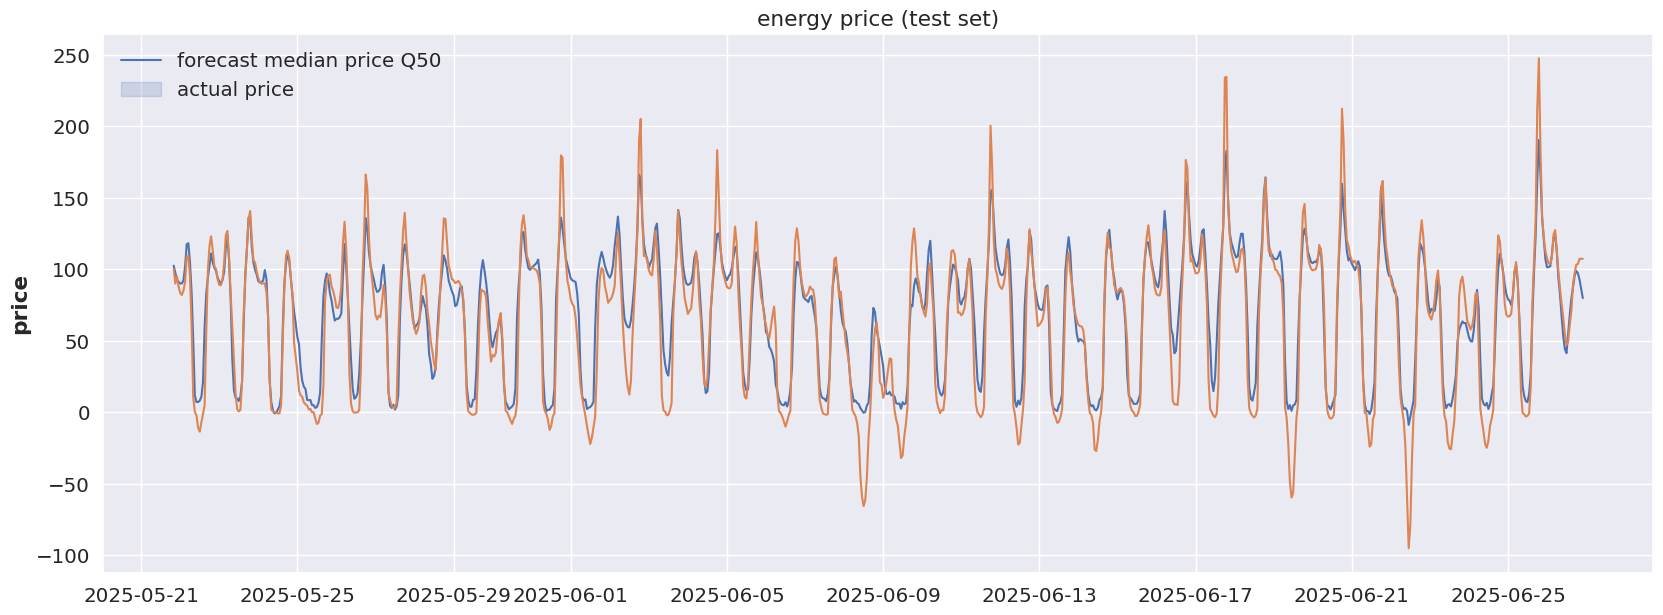

In [26]:
# plot the forecast
plt.figure(100, figsize=(20, 7))
sns.set(font_scale=1.3)
p = sns.lineplot(x = "Time", y = "Q50", data = dfY, palette="coolwarm")
sns.lineplot(x = "Time", y = "Actual", data = dfY, palette="coolwarm")
plt.legend(labels=["forecast median price Q50", "actual price"])
p.set_ylabel("price")
p.set_xlabel("")
p.set_title("energy price (test set)");

# Out-of Sample Forecast

In [28]:
# choose forecast horizon: k hours beyond end of test set
k = 12

n_FC = k + len(ts_ttest)   # length of test set + k hours
print("forecast beyond end of training set:", n_FC,
      "hours beyond", ts_ttrain.end_time())

# last 24 hours of feature covariates available => copy them to future 24 hours:
covF_t_fut = covF_t.concatenate(    other=covF_t.tail(size=24),
                                    ignore_time_axis=True)
# combine feature and time covariates:
cov_t_fut = covF_t_fut.concatenate(covT_t.slice_intersect(covF_t_fut), axis=1)
cov_t_fut.to_dataframe().iloc[[0,-1]]

forecast beyond end of training set: 879 hours beyond 2025-05-21 19:00:00


,price_dayahead,gen_gas,gen_lig,gen_coal,gen_bio,gen_hyd_pump,gen_hyd_res,load_actual,humidity_Aachen,humidity_Stuttgart,...,max_temp_Berlin,max_temp_Munchen,max_temp_Hamburg,max_temp_Stuttgart,gen_solar,hour,day_of_week,month,year,holidays
Time,,,,,,,,,,,,,,,,,,,,,
2024-06-30 22:00:00,0.29,0.11,0.60,0.11,0.24,0.08,0.66,0.19,0.81,0.81,...,0.55,0.55,0.55,0.55,0.00,0.96,1.00,0.45,0.00,0.00
2025-06-27 22:00:00,0.31,0.10,0.42,0.20,0.31,0.04,0.06,0.38,0.68,0.68,...,0.66,0.66,0.66,0.66,-0.00,0.96,0.67,0.45,1.00,0.00


In [ ]:
# forecast from end of training set until k hours beyond end of test set
ts_tpred = model.predict(   n=n_FC,
                            past_covariates=cov_t_fut,
                            num_samples=N_SAMPLES,
                            verbose=True,
                            n_jobs=N_JOBS)
print("start:", ts_tpred.start_time(), "; end:",ts_tpred.end_time())


In [30]:
# retrieve forecast series for chosen quantiles,
# inverse-transform each series,
# insert them as columns in a new dataframe dfY
q50_RMSE = np.inf
q50_MAPE = np.inf
ts_q50 = None
pd.options.display.float_format = '{:,.2f}'.format
dfY = pd.DataFrame()
#dfY["Actual"] = TimeSeries.to_series(ts_test)

# call helper function predQ, once for every quantile
_ = [predQ(ts_tpred, q) for q in QUANTILES]

# move Q50 column to the left, then insert Actual column
col = dfY.pop("Q50")
dfY.insert(0, col.name, col)
dfY.insert(0, "Actual", TimeSeries.to_series(ts_test))

# show first and last 13 timestamps of forecast
dfY.iloc[np.r_[0:1, -13:0]]

RMSE: 18.62
MAPE: 117.20


,Actual,Q50,Q01,Q10,Q20,Q80,Q90,Q99
Time,,,,,,,,
2025-05-21 20:00:00,100.20,103.55,90.54,95.97,98.07,105.43,107.35,122.39
2025-06-26 22:00:00,107.32,79.86,67.57,73.36,75.37,83.20,88.31,97.79
2025-06-26 23:00:00,NaN,78.92,69.75,72.96,74.70,82.15,85.45,96.34
2025-06-27 00:00:00,NaN,97.83,83.88,90.23,92.91,100.39,103.17,116.10
2025-06-27 01:00:00,NaN,101.45,92.44,95.54,96.85,104.22,106.15,114.40
2025-06-27 02:00:00,NaN,99.84,91.35,94.51,95.93,102.38,103.91,113.39
2025-06-27 03:00:00,NaN,108.23,95.71,102.02,103.81,112.51,117.79,127.88
2025-06-27 04:00:00,NaN,118.62,106.64,113.42,114.48,123.00,124.69,140.09
2025-06-27 05:00:00,NaN,125.84,110.77,116.31,119.40,129.35,137.72,148.86


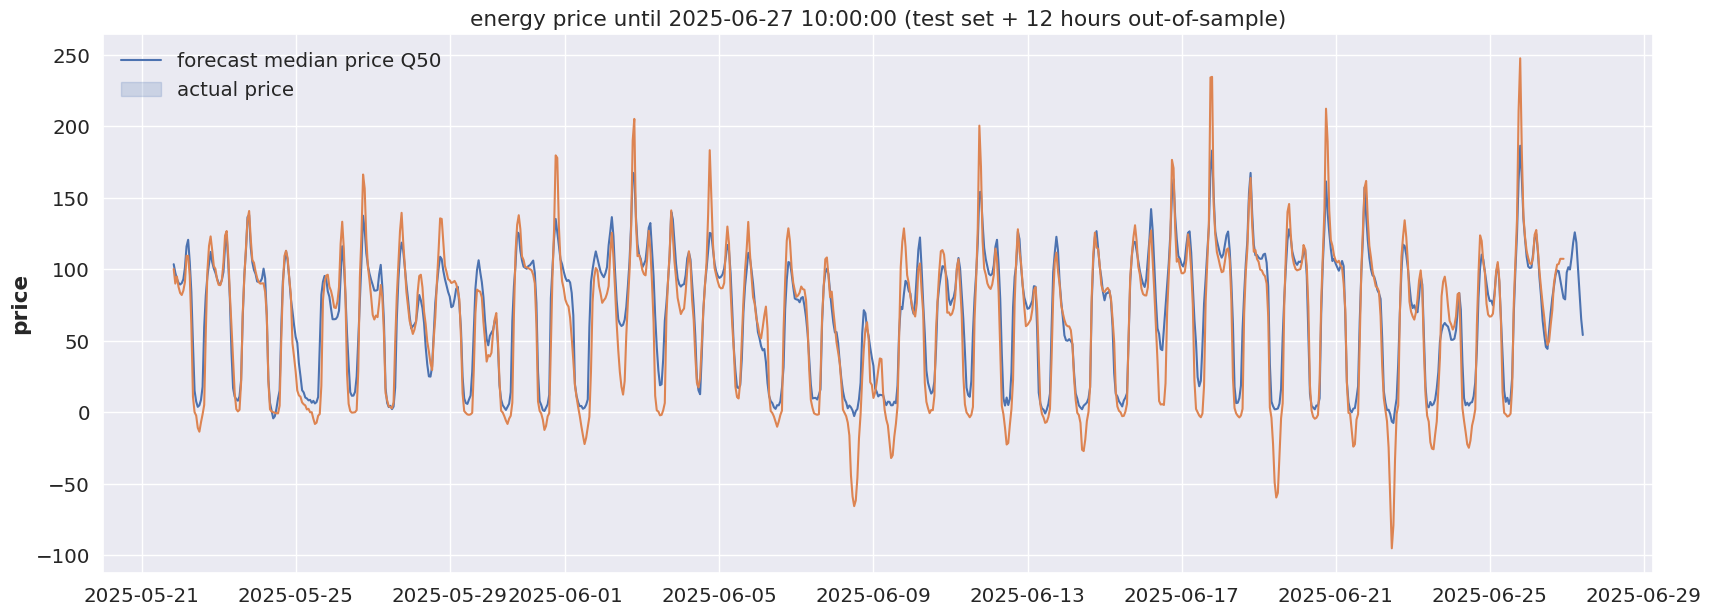

In [31]:
# plot the forecast
plt.figure(100, figsize=(20, 7))
sns.set(font_scale=1.3)
p = sns.lineplot(x = "Time", y = "Q50", data = dfY, palette="coolwarm")
sns.lineplot(x = "Time", y = "Actual", data = dfY, palette="coolwarm")
plt.legend(labels=["forecast median price Q50", "actual price"])
p.set_ylabel("price")
p.set_xlabel("")
end = ts_tpred.end_time()
p.set_title("energy price until {} (test set + {} hours out-of-sample)".format(end, k));